# Leggere dati da file (e un po' di trucchi)
Di solito la quantità di dati da analizzare è tale che non è pensabile di
poterli immettere manualmente in una o più lista come abbiamo fatto noi.
Normalmente i dati sono memorizzati su un file ed è necessario leggerli.
Prendiamo in considerazione il file di testo `heroes.csv` contenuto nella
directory `data`: esso contiene 735 righe, ognuna con le informazioni relative
a un supereroe, separate da virgola. Le prime tre righe del file sono indicate
di seguito.

In [1]:
!head -3 data/heroes.csv

Il formato CSV (comma separated values) indica un record su ogni riga,
separando i campi corrispondenti con un carattere speciale che di norma, ma non
sempre, è la virgola. Come si può vedere, nel nostro caso la prima riga indica
il tipo di dati presente in ogni riga (sono gli stessi a cui abbiamo fatto
riferimento finora), viene usato il punto e virgola per separare i campi (ciò
permette di inserire delle virgole nei luoghi di nascita, come nel primo
record) e possono esistere dei valori mancanti (quali per esempio il luogo di
nascita nel secondo record).

La cella seguente legge i contenuti del file e li inserisce nella lista
`heroes`.

In [2]:
import csv

with open('data/heroes.csv', 'r') as heroes_file:
  heroes_reader = csv.reader(heroes_file, delimiter=';', quotechar='"')
  heroes = list(heroes_reader)[1:]

Nella cella:

- l'apertura del file è fatta utilizzando la parola chiave `with`: nelle
  istruzioni indentate che seguono è possibile usare `heroes_file` per fare
  riferimento all'oggetto che descrive il file, e quest'ultimo sarà
  automaticamente chiuso, anche nel caso in cui vengano lanciate eccezioni,
  all'uscita del corpo di `with`;
- la funzione che apre il file accetta come primo argomento il pathname
  corrispondente e come secondo una stringa che indica come effettuare
  l'accesso: `'rb'` indica lettura in modalità binaria, cosa che permette di
  non doversi preoccupare di dover gestire come il sistema operativo indica la
  fine linea nei file di testo;
- la lettura effettiva del file è demandata al modulo `csv` che si occupa
  direttamente di convertire dal formato CSV: la funzione `csv.reader` gestisce
  anche il fatto di avere un separatore diverso dalla virgola e permette di
  inserire un punto e virgola in un campo a patto di delimitare quest'ultimo
  tra doppi apici;
- la parola chiave `list` converte il contenuto del file in una lista, e da
  quest'ultima si esclude la prima riga (in quanto essa contiene le
    intestazioni dei campi).

```{admonition} Nomenclatura
:class: naming
In generale usando il nome di un tipo come se fosse una funzione è possibile
effettuare conversioni tra tipi di dati: per esempio `int('42')` converte una
stringa in intero e `str(42)` effettua la conversione inversa.
```

Proviamo a visualizzare i primi due record (che corrispondono alle due righe
sopra mostrate):

In [3]:
heroes[:2]

[['A-Bomb',
  'Richard Milhouse Jones',
  'Scarsdale, Arizona',
  'Marvel Comics',
  '203.21000000000001',
  '441.94999999999999',
  'M',
  '2008',
  'Yellow',
  'No Hair',
  '100',
  'moderate'],
 ['Abraxas',
  'Abraxas',
  'Within Eternity ',
  'Marvel Comics',
  '',
  '',
  'M',
  '',
  'Blue',
  'Black',
  '100',
  'high']]

Si vede che tutti i dati sono indicati come stringhe (vedremo più avanti un
modo più efficiente di rilevare i diversi tipi di dati in modo corretto), e che
la stringa vuota è usata per codificare i dati mancanti.

Per poter generare il grafico delle frequenze assolute con i nuovi dati è
necessario estrarre l'anno di prima apparizione da ogni record. Potremmo farlo
anche in questo caso usando il trucco di trasporre il corrispondente array, ma
c'è un modo molto più efficiente che prende il nome di _list comprehension_,
una sintassi specifica di python. Invece di creare una lista in modo
_estensivo_ (cioè elencando i suoi elementi), la list comprehension permette di
crearla in modo _intensivo_, specificando come trasformare gli elementi di
un'altra lista che già abbiamo a disposizione. La sintassi di base di una _list
comprehension_ è

```
[f(e) for e in l]
```

dove `f(e)` indica una funzione o un'espressione che dipende dalla variabile
muta `e` e `l` è una lista di cui quindi `e` indica il generico elemento.
Questa espressione permette di costruire una nuova lista in cui il primo
elemento è il risultato del calcolo di `f` sul primo elemento di `l`, il
secondo è il risultato di `f` secondo elemento di `l` e così via. È inoltre
possibile utilizzre la sintassi `[f(e) for e in l if g(e)]`, che indica che
nella creazione della nuova lista bisogna limitarsi a considerare gli elementi
`e` della lista originale che rendono vera l'espressione `g(e)`. Pertanto

In [4]:
years = [int(h[7]) for h in heroes if h[7]]

assegna a `years` la lista che contiene l'anno di prima apparizione di ogni
supereroe (che infatti occorre in ottava posizione), convertito da stringa a
intero, ma senza considerare le stringhe vuote (in python la stringa vuota
  equivale a un'espressione logica falsa esattamente come `0` o `0.` in C, e le
  altre stringhe equivalgono a un'espressione logica vera), operazione
  necessaria altrimenti la conversione a intero di un dato mancante lancerebbe
  un'eccezione.

```{margin}
Per comodità è riportato anche il codice della funzione `get_sorted_counts`
```
A questo punto è possibile generare il grafico delle frequenze assolute:

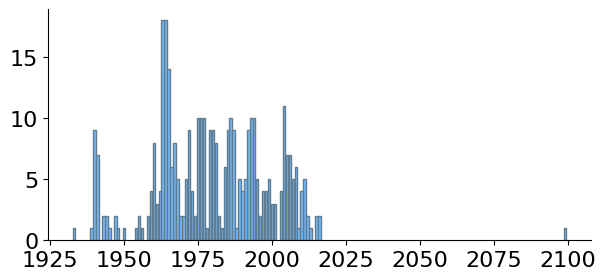

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('sds.mplstyle')

def get_sorted_counts(sequence):
    counts = {}

    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1

    pairs = counts.items()
    return sorted(pairs, key=lambda p:p[1], reverse=True)

counts = get_sorted_counts(years)
x, y = np.array(counts).transpose()
plt.bar(x, y)
plt.show()

Il grafico appare "spostato" verso sinistra, a causa della presenza di una
barra in prossimità dell'anno 2100. Potrebbe essere un supereroe effettivamente
nato nel futuro, oppure si potrebbe trattare di un dato errato. Si tratta di
una situazione più comune di quanto non si possa pensare: queste misurazioni
affette da rumore prendono il nome di _dati fuori scala_ o _outlier_ e più
avanti vedremo come gestirle. Per ora limitiamoci a vedere quale sia questo
valore. Possiamo farlo usando una list comprehension appena più complicata di
quella vista poco fa:

In [6]:
[year for year in years if year > 2020]

[2099]

In soldoni, la presenza dell'anno 2099 causa lo spostamento del grafico.
Potremmo eliminare il record corrispondente dal nostro dataset, ma così facendo
perderemmo i valori per gli altri campi che non è detto siano anch'essi degli
outlier. Un modo molto più pratico di procedere è quello di visualizzare il
grafico restringendo le ascisse all'intervallo temporale che va dal 1950 al
2015: ciò viene fatto invocando la funzione `plt.xlim` e passandole una coppia
con gli estremi di questo intervallo. Già che ci siamo, possiamo anche
impostare l'ampiezza dell'asse delle ordinate in modo che ci sia un po' di
spazio sopra la barra che corrisponde alla frequenza massima:

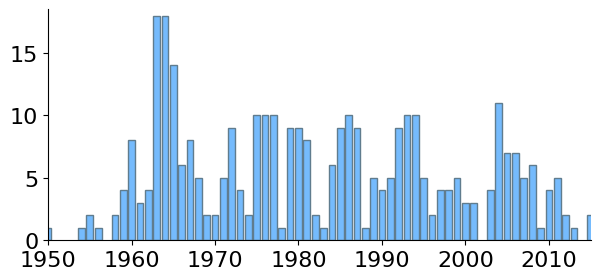

In [7]:
plt.bar(x, y)
plt.xlim((1950, 2015))
plt.ylim((0, 18.5))
plt.show()

```{admonition} Nomenclatura
:class: naming
In teoria, una volta ottenuta la lista `counts`, è possibile generare il
grafico (ridmensionamento dei suoi assi a parte) usando l'istruzione più
compatta `plt.bar(*np.array(counts[1:]).T)` in cui

- l'invocazione del metodo `transpose` è sostituita dall'utilizzo della
  _proprietà_ `T`: si tratta essenzialmente della stessa cosa, ma permette di
  essere più succinti;
- invece di assegnare a due variabili `x` e `y` le liste di ascisse e ordinate,
  si usa l'operatore `*` per effettuare un'altra forma di _unpacking_ delle
  liste in modo che i due elementi della lista restituita da `T` vengano
  rispettivamente usati come primo e secondo argomento di `np.bar`.

Va in ogni caso sottolineato che il minor numero di linee si paga con del
codice più complesso e quindi meno facile da leggere e da correggere in caso di
errore, quindi almeno fino a quando non si è abbastanza confidenti nel
linguaggio è meglio non ricorrere a soluzioni troppo complicate.
```